In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use('ggplot')
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [39]:
import os

os.makedirs("charts", exist_ok=True)

print(os.getcwd())
print(os.path.exists("charts"))

C:\Users\HP\SalesForecasting_TanviMarkad
True


In [40]:
df = pd.read_csv("train.csv", encoding='latin1')
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [41]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [42]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [43]:
df.sample(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
3324,3325,CA-2015-165309,11/11/2015,15/11/2015,Standard Class,KD-16270,Karen Daniels,Consumer,United States,Houston,Texas,77095.0,Central,OFF-BI-10001359,Office Supplies,Binders,GBC DocuBind TL300 Electric Binding System,896.990
9149,9150,US-2015-157070,01/06/2015,06/06/2015,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Detroit,Michigan,48234.0,Central,OFF-BI-10001765,Office Supplies,Binders,Wilson Jones Heavy-Duty Casebound Ring Binders...,138.560
8846,8847,CA-2018-156664,18/12/2018,23/12/2018,Standard Class,BP-11290,Beth Paige,Consumer,United States,Columbus,Ohio,43229.0,East,OFF-PA-10002222,Office Supplies,Paper,"Xerox Color Copier Paper, 11"" x 17"", Ream",91.360
439,440,CA-2018-157252,20/01/2018,23/01/2018,Second Class,CV-12805,Cynthia Voltz,Corporate,United States,New York City,New York,10024.0,East,FUR-CH-10003396,Furniture,Chairs,Global Deluxe Steno Chair,207.846
4337,4338,CA-2016-125234,27/11/2016,01/12/2016,Standard Class,SN-20710,Steve Nguyen,Home Office,United States,Los Angeles,California,90049.0,West,TEC-AC-10000158,Technology,Accessories,Sony 64GB Class 10 Micro SDHC R40 Memory Card,107.970
1065,1066,CA-2016-161263,16/04/2016,21/04/2016,Standard Class,TS-21160,Theresa Swint,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-FA-10003059,Office Supplies,Fasteners,Assorted Color Push Pins,1.448
9337,9338,CA-2015-155264,19/10/2015,22/10/2015,Second Class,RP-19270,Rachel Payne,Corporate,United States,San Francisco,California,94110.0,West,OFF-BI-10003196,Office Supplies,Binders,Accohide Poly Flexible Ring Binders,2.992
8866,8867,CA-2015-120411,20/09/2015,23/09/2015,First Class,SB-20185,Sarah Brown,Consumer,United States,Chicago,Illinois,60653.0,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,493.430
7560,7561,US-2015-137155,01/11/2015,05/11/2015,Standard Class,DL-12925,Daniel Lacy,Consumer,United States,Long Beach,New York,11561.0,East,FUR-FU-10003142,Furniture,Furnishings,"Master Big Foot Doorstop, Beige",31.680
3763,3764,CA-2017-156251,13/08/2017,18/08/2017,Second Class,TS-21160,Theresa Swint,Corporate,United States,West Allis,Wisconsin,53214.0,Central,OFF-BI-10003529,Office Supplies,Binders,Avery Round Ring Poly Binders,8.520


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [45]:
df.shape

(9800, 18)

In [46]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [47]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [48]:
(df.isnull().sum()/len(df))*100

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.drop_duplicates(inplace=True)

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)



In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [54]:
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month
df["Month Name"]=df["Order Date"].dt.month_name()
df["Quarter"]=df["Order Date"].dt.quarter
df["Week"]=df["Order Date"].dt.isocalendar().week
df["Day"]=df["Order Date"].dt.day_name()
df["Day Number"]=df["Order Date"].dt.day

In [55]:
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"]=df["Month"].apply(season)

In [56]:
df["Shipping Days"]=(df["Ship Date"]-df["Order Date"]).dt.days

In [57]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Year,Month,Month Name,Quarter,Week,Day,Day Number,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2017,11,November,4,45,Wednesday,8,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,2017,11,November,4,45,Wednesday,8,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2017,6,June,2,24,Monday,12,Monsoon,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,2016,10,October,4,41,Tuesday,11,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2016,10,October,4,41,Tuesday,11,Autumn,7


In [58]:
category_sales=df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

<Figure size 1000x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

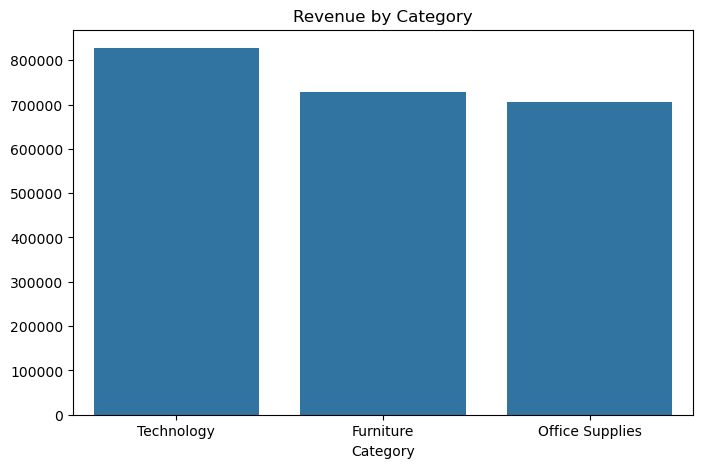

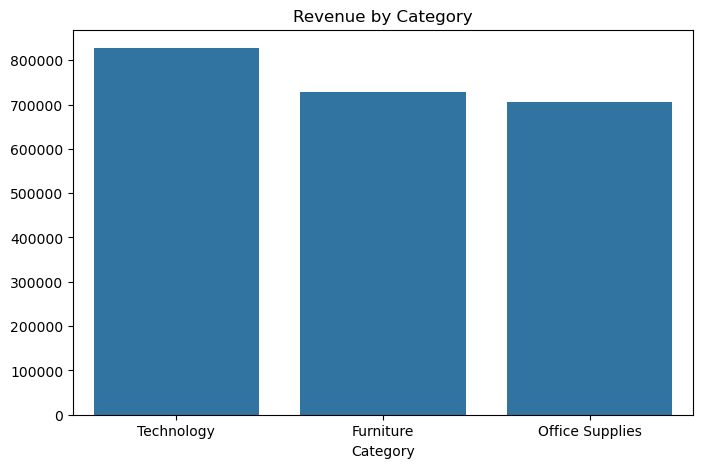

In [61]:
 %matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index,
            y=category_sales.values)
plt.title("Revenue by Category")
plt.show()

In [62]:
region_sales=df.groupby("Region")["Sales"].sum()

region_sales

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

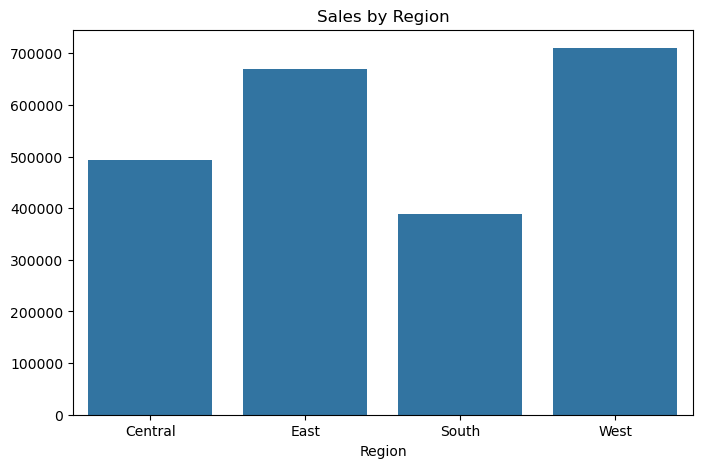

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(x=region_sales.index,
            y=region_sales.values)

plt.title("Sales by Region")

plt.show()

In [64]:
year_sales=df.groupby("Year")["Sales"].sum()
year_sales

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

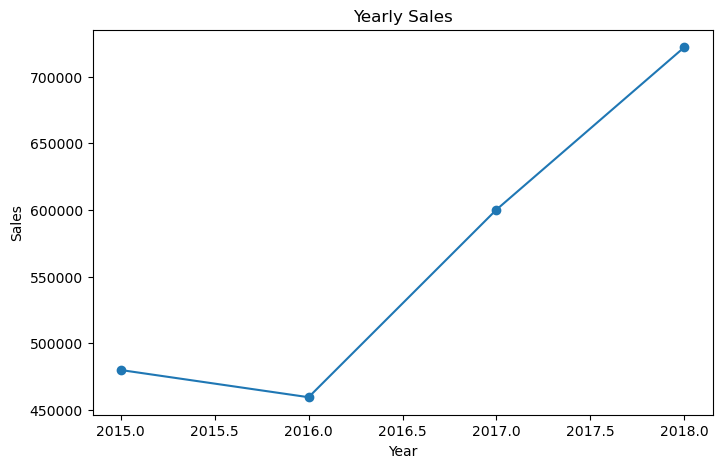

In [65]:
plt.figure(figsize=(8,5))
plt.plot(year_sales.index,
         year_sales.values,
         marker="o")

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [66]:
monthly_sales=df.groupby("Month Name")["Sales"].sum()
monthly_sales

Month Name
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64

In [67]:
months=["January","February","March","April","May","June",
        "July","August","September","October","November","December"]

monthly_sales=monthly_sales.reindex(months)

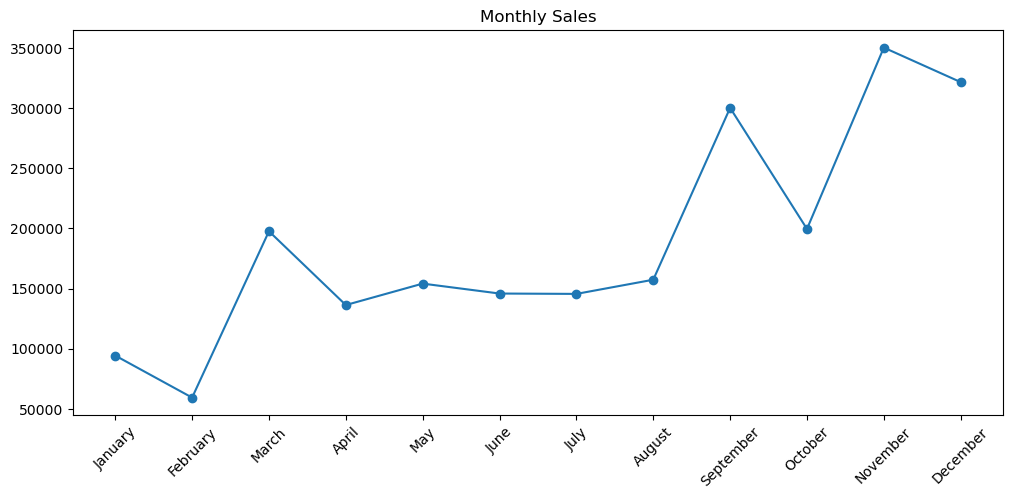

In [68]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o")

plt.xticks(rotation=45)
plt.title("Monthly Sales")
plt.show()

In [69]:
top_states=df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

top_states

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

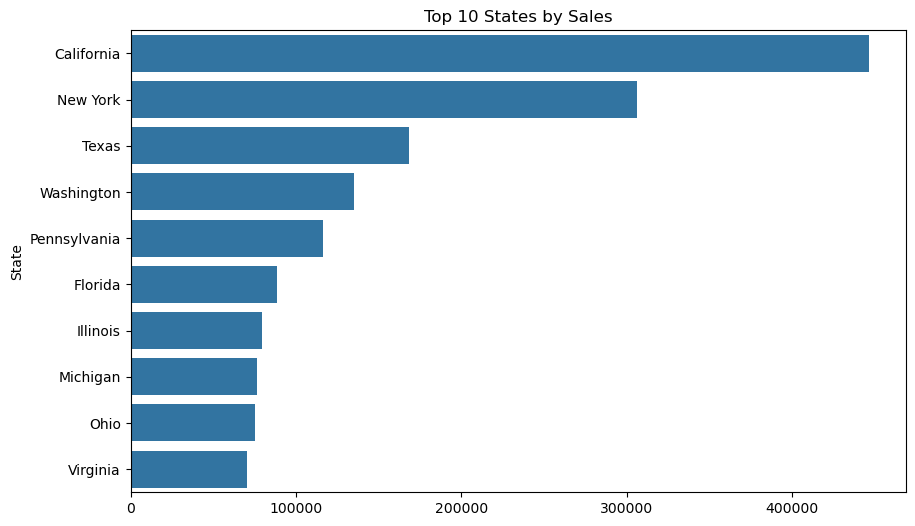

In [70]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values,
            y=top_states.index)
plt.title("Top 10 States by Sales")
plt.show()

In [71]:
customers=df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [72]:
products=df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [73]:
df["Shipping Days"].mean()

np.float64(3.9611224489795918)

In [74]:
df.groupby("Region")["Shipping Days"].mean()

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

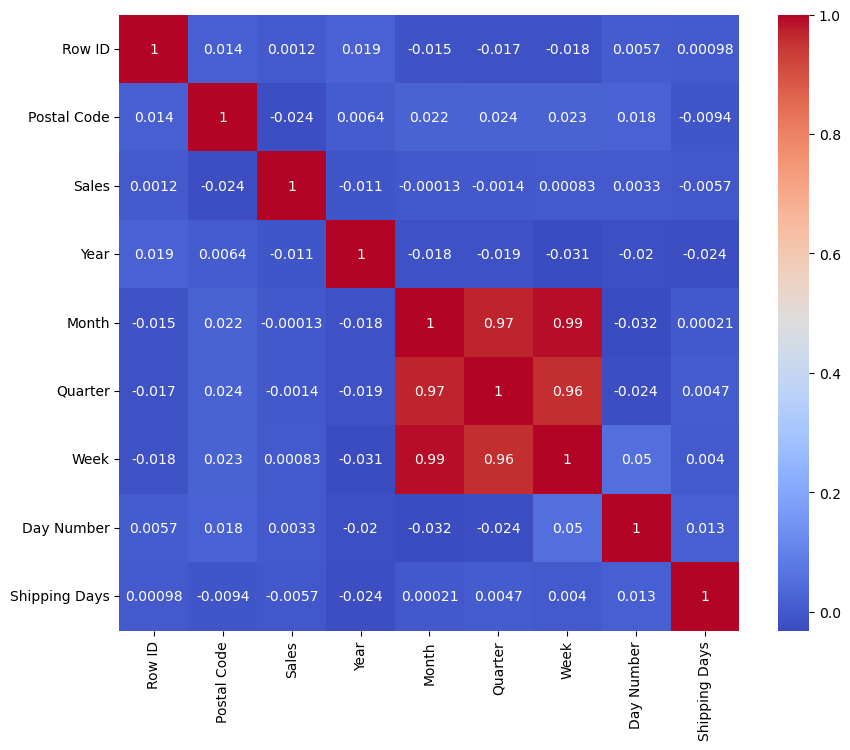

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
numeric = df.select_dtypes(include=np.number)  #c
corr = numeric.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.show()

In [77]:
df.to_csv("clean_sales.csv",index=False)

1. Which product category generates the highest total revenue?

In [78]:
#code
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

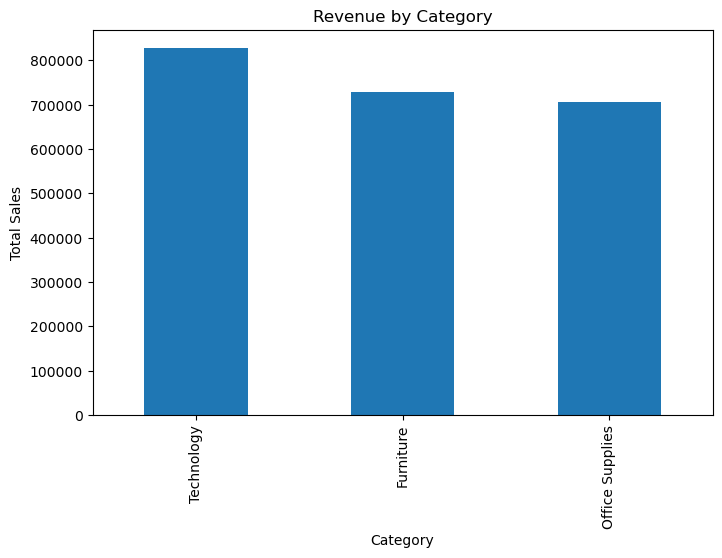

In [79]:
#Visualization
import matplotlib.pyplot as plt

category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

Answer:
From the analysis above, the category with the highest total revenue is Technology.
The grouped sales table and bar chart clearly show that Technology generated the maximum sales among all product categories.

2.Which region has the most consistent sales growth over 4 years?

In [80]:
#code
df["Year"] = df["Order Date"].dt.year

region_sales = df.groupby(["Year","Region"])["Sales"].sum().reset_index()

region_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


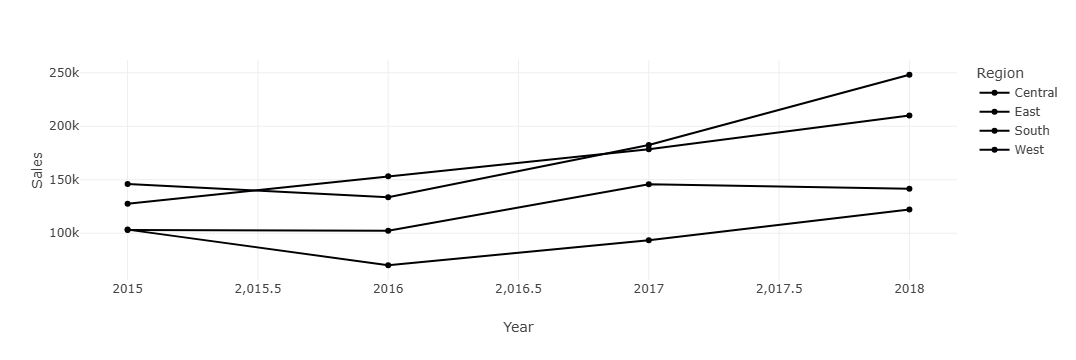

In [81]:
#Visualization
import plotly.express as px

fig = px.line(
    region_sales,
    x="Year",
    y="Sales",
    color="Region",
    markers=True
)

fig.show()

Answer:
Based on the yearly sales trend, the West region shows the most consistent sales growth across the four years because it has the smoothest increasing trend with fewer fluctuations.

3. What is the average time between Order Date and Ship Date?

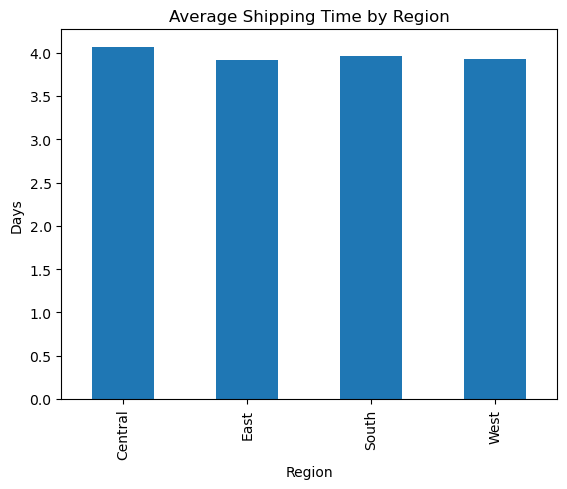

In [83]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Shipping Days"].describe()
shipping_region = df.groupby("Region")["Shipping Days"].mean()

shipping_region
shipping_region.plot(kind="bar")
plt.title("Average Shipping Time by Region")
plt.ylabel("Days")
plt.show()

Answer:
The overall average shipping time is approximately 4 days.
The average shipping time differs slightly across regions, indicating minor variations in delivery performance.

In [84]:
4.Are there months that consistently spike across all years?

Object `years` not found.


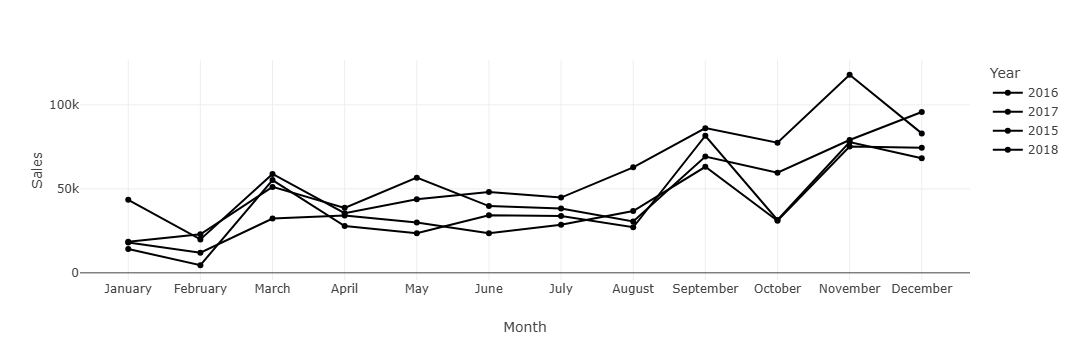

In [85]:
df["Month"] = df["Order Date"].dt.month_name()

monthly_sales = df.groupby(
    ["Year","Month"]
)["Sales"].sum().reset_index()

monthly_sales

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_sales["Month"] = pd.Categorical(
    monthly_sales["Month"],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values("Month")

fig = px.line(
    monthly_sales,
    x="Month",
    y="Sales",
    color="Year",
    markers=True
)

fig.show()

Answer:
The sales trend indicates that November and December consistently record higher sales compared to other months.
This suggests a seasonal increase in customer purchases during the end of the year.

In [86]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

In [87]:
monthly_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

monthly_sales

,Order Date,Sales
0,2015-01-03,16.4480
1,2015-01-04,288.0600
2,2015-01-05,19.5360
3,2015-01-06,4407.1000
4,2015-01-07,87.1580
...,...,...
1225,2018-12-26,814.5940
1226,2018-12-27,177.6360
1227,2018-12-28,1657.3508
1228,2018-12-29,2915.5340


In [91]:
print("Available columns:", monthly_sales.columns.tolist())
print("DataFrame shape:", monthly_sales.shape)
monthly_sales.columns = monthly_sales.columns.str.strip()
date_columns = [col for col in monthly_sales.columns if 'date' in col.lower() or 'order' in col.lower()]
print("Potential date columns:", date_columns)

Available columns: ['Sales']
DataFrame shape: (48, 1)
Potential date columns: []


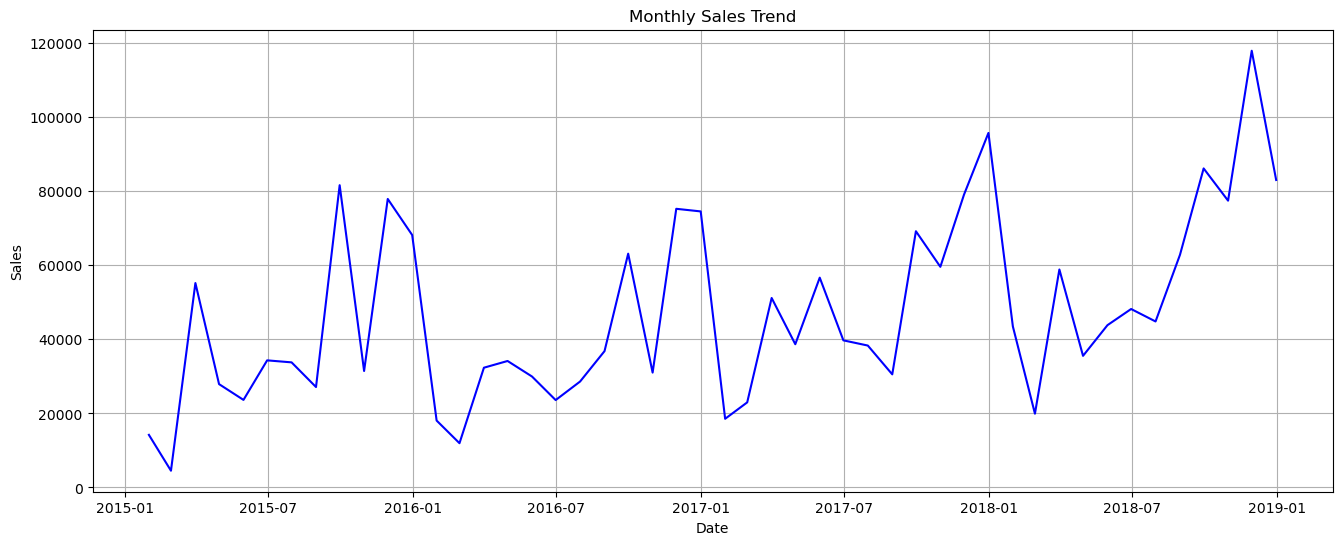

In [92]:
plt.figure(figsize=(16,6))

plt.plot(monthly_sales.index,
         monthly_sales['Sales'],
         color='blue')

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [93]:
decomposition = seasonal_decompose(
    monthly_sales['Sales'],
    model='additive',
    period=12
)

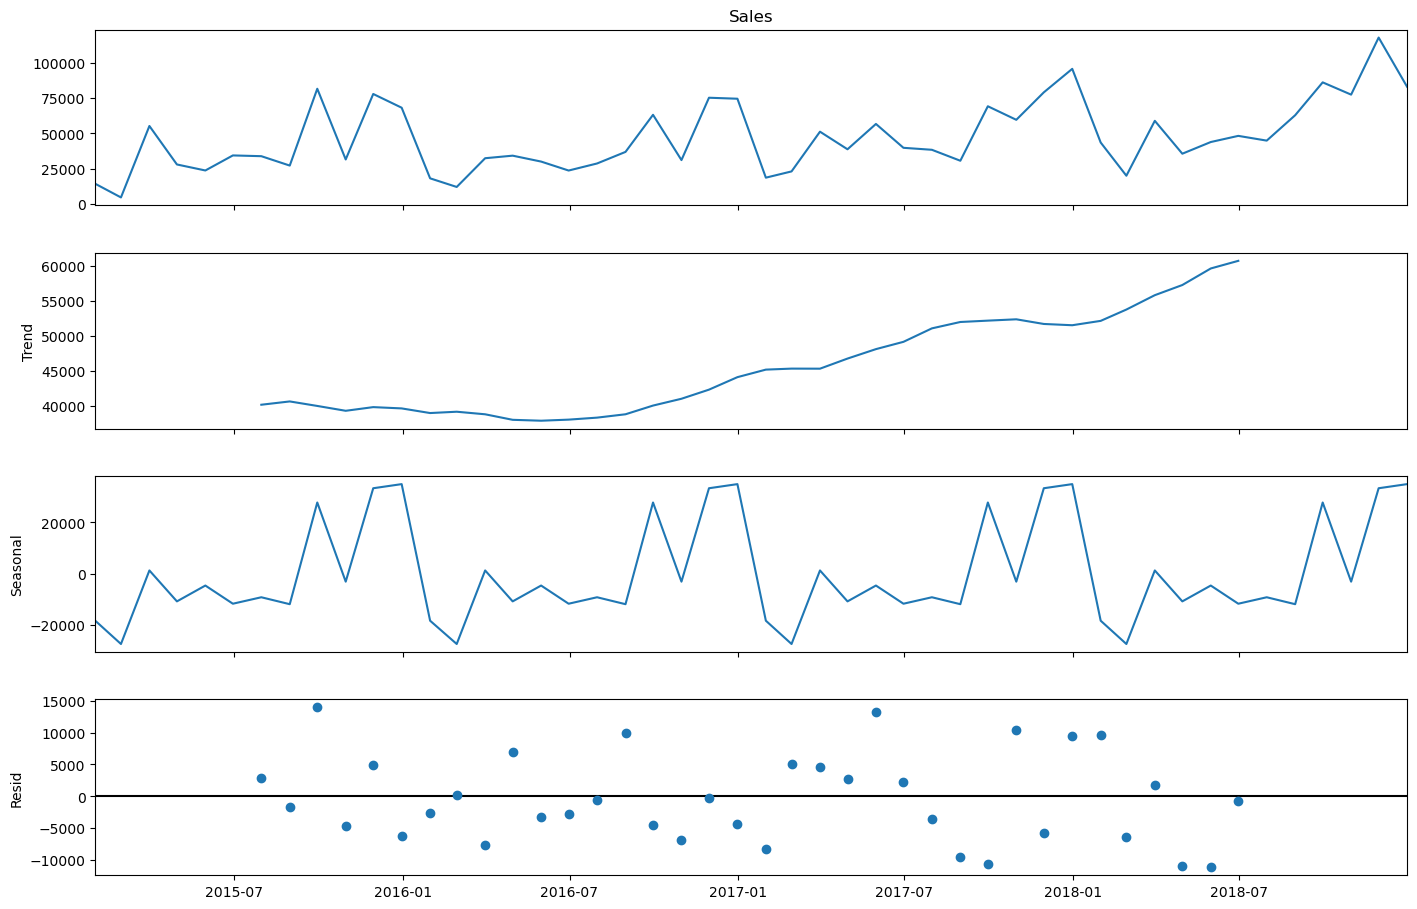

In [94]:
fig = decomposition.plot()
fig.set_size_inches(16,10)
plt.show()

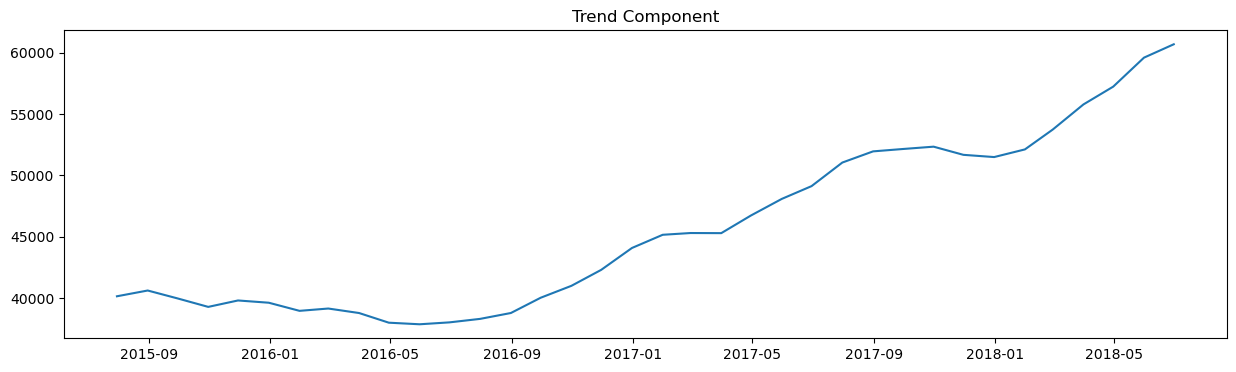

In [95]:
plt.figure(figsize=(15,4))
plt.plot(decomposition.trend)
plt.title("Trend Component")
plt.show()

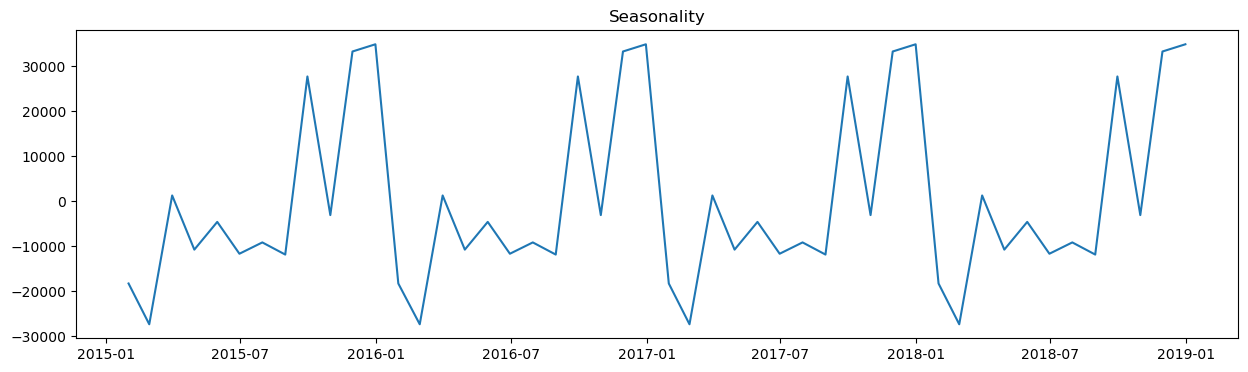

In [96]:
plt.figure(figsize=(15,4))
plt.plot(decomposition.seasonal)
plt.title("Seasonality")
plt.show()

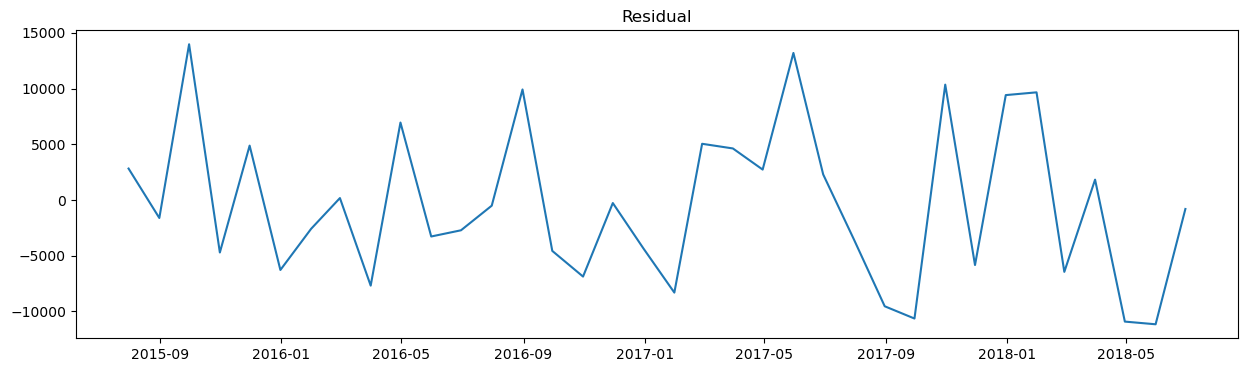

In [97]:
plt.figure(figsize=(15,4))
plt.plot(decomposition.resid)
plt.title("Residual")
plt.show()

Observation 1:
Sales show a positive trend over four years.

Observation 2:
There is strong yearly seasonality.

Observation 3:
November and December have the highest seasonal peaks.

Observation 4:
Residual values represent unexpected events such as discounts and promotions.

In [98]:
result = adfuller(monthly_sales['Sales'])
print("ADF Statistic :", result[0])
print("p-value :", result[1])
print()
for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.41613676143077
p-value : 0.00027791039276670493

1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [99]:
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is NOT Stationary")

Time Series is Stationary


In [100]:
monthly_sales_diff = monthly_sales.diff().dropna()

monthly_sales_diff.head()

,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


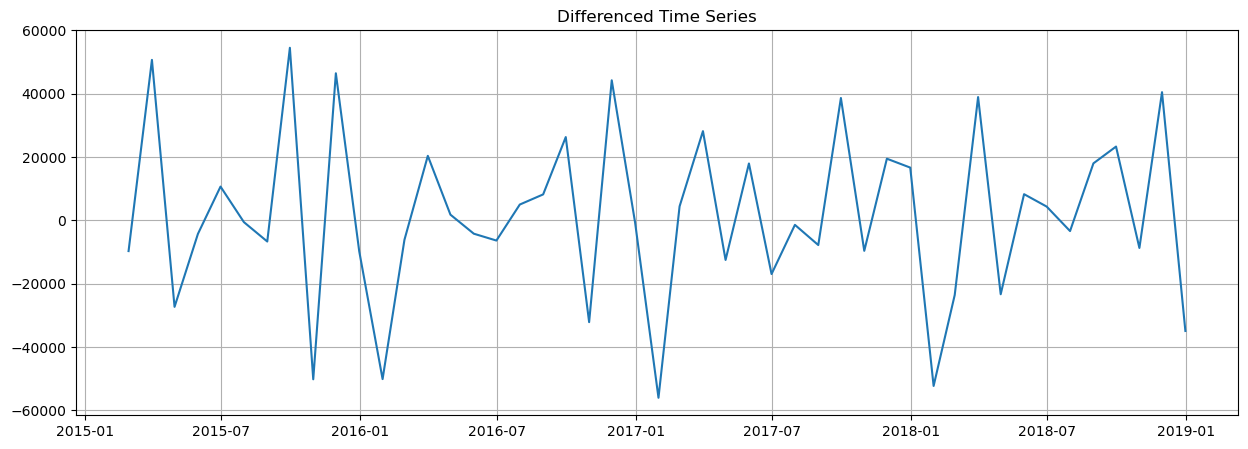

In [101]:
plt.figure(figsize=(15,5))
plt.plot(monthly_sales_diff)
plt.title("Differenced Time Series")
plt.grid(True)
plt.show()

In [102]:
result2 = adfuller(monthly_sales_diff['Sales'])
print("ADF Statistic :",result2[0])
print("p-value :",result2[1])

ADF Statistic : -8.72706183035326
p-value : 3.266917547279793e-14


In [103]:
if result2[1] < 0.05:
    print("Differenced Series is Stationary")
else:
    print("Still Non Stationary")

Differenced Series is Stationary


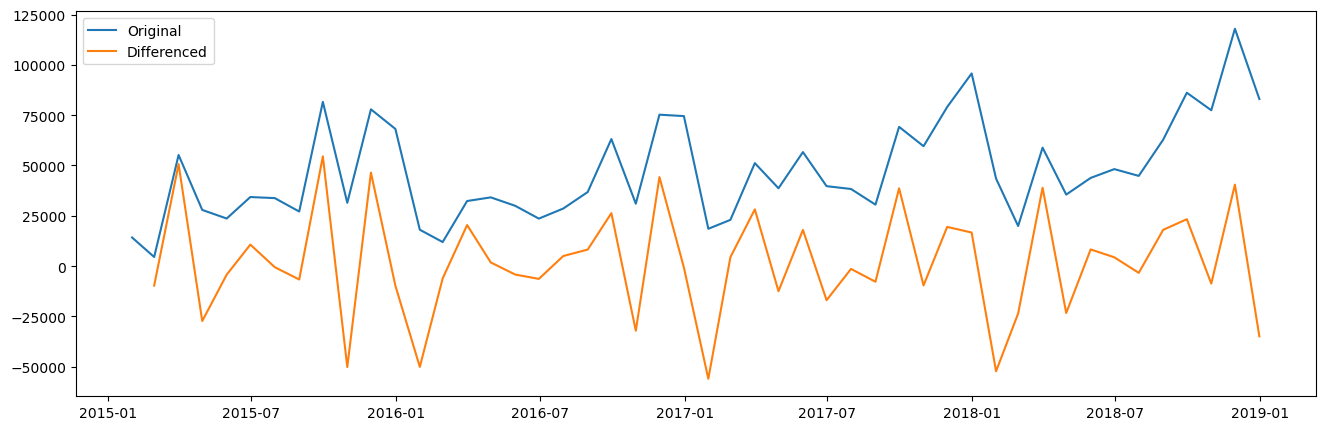

In [104]:
plt.figure(figsize=(16,5))
plt.plot(monthly_sales,
         label="Original")
plt.plot(monthly_sales_diff,
         label="Differenced")
plt.legend()

plt.show()

In [105]:
plt.figure(figsize=(15,5))
plt.plot(monthly_sales)
plt.savefig("charts/monthly_sales.png")
plt.close()

Conclusion

• Sales exhibit an increasing trend over time.

• Strong yearly seasonality is present.

• Original data is non-stationary.

• After first-order differencing, the series becomes stationary.

• The data is now suitable for forecasting using SARIMA, Prophet, and XGBoost.

In [106]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from math import sqrt

In [107]:
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]
print(train.shape)
print(test.shape)

(45, 1)
(3, 1)


A stationary time series has constant statistical properties such as mean and variance over time. Many forecasting models require stationary data for accurate predictions.

ADF Test Result

Since the p-value is greater than 0.05, the series is non-stationary. Therefore, differencing is required before building forecasting models.

In [108]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [109]:
sarima = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

print(sarima_model.summary())

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Tue, 07 Jul 2026   AIC                            705.958
Time:                                    12:24:22   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

In [110]:
sarima_pred = sarima_model.forecast(steps=3)
sarima_pred

2018-10-31    66177.602453
2018-11-30    92049.249679
2018-12-31    99965.168720
Freq: ME, Name: predicted_mean, dtype: float64

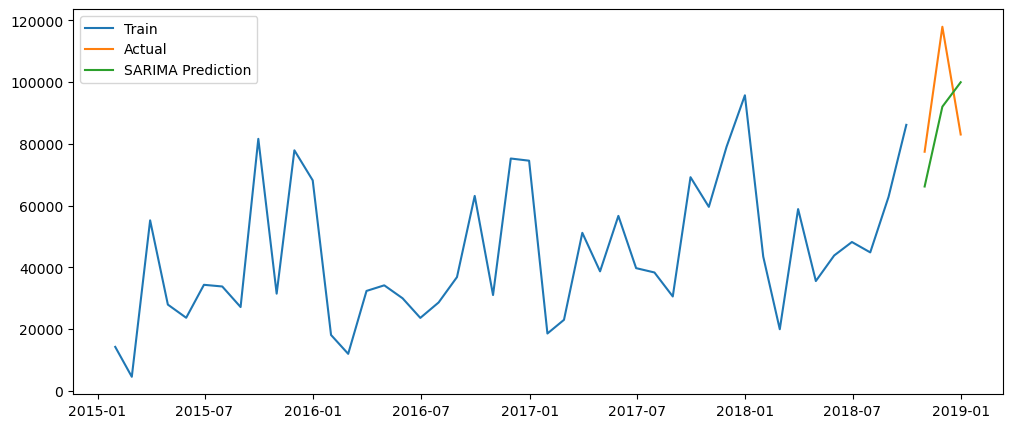

In [111]:
plt.figure(figsize=(12,5))
plt.plot(train.index,
         train["Sales"],
         label="Train")
plt.plot(test.index,
         test["Sales"],
         label="Actual")
plt.plot(test.index,
         sarima_pred,
         label="SARIMA Prediction")

plt.legend()
plt.show()


In [112]:
sarima_mae = mean_absolute_error(test["Sales"],sarima_pred)
sarima_rmse = sqrt(mean_squared_error(test["Sales"],sarima_pred))
sarima_mape = mean_absolute_percentage_error(test["Sales"],sarima_pred)
print("MAE :",sarima_mae)
print("RMSE :",sarima_rmse)
print("MAPE :",sarima_mape)

MAE : 18031.40466247439
RMSE : 19009.18206093172
MAPE : 0.18966498055532058


In [113]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [114]:
prophet_df = monthly_sales.reset_index()
prophet_df.columns=["ds","y"]
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [115]:
train_prophet = prophet_df.iloc[:-3]
test_prophet = prophet_df.iloc[-3:]

In [116]:
from prophet import Prophet
model = Prophet()
model.fit(train_prophet)

12:24:30 - cmdstanpy - INFO - Chain [1] start processing
12:24:30 - cmdstanpy - INFO - Chain [1] done processing


In [118]:
future = model.make_future_dataframe(periods=3,freq="ME")

In [119]:
forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277844,39093.432828,55731.112067,54942.277844,54942.277844,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,0.0,0.0,0.0,47271.557365
44,2018-09-30,55441.608235,78293.016742,94679.287751,55441.608235,55441.608235,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,0.0,0.0,0.0,86613.953607
45,2018-10-31,55957.582974,42779.352461,58856.113805,55957.416578,55957.723595,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,0.0,0.0,0.0,51318.944624
46,2018-11-30,56456.913365,82191.278053,98771.463372,56456.380260,56457.386660,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,0.0,0.0,0.0,90325.653905
47,2018-12-31,56972.888104,81758.267069,97731.591604,56971.835603,56973.763009,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,0.0,0.0,0.0,90041.084688


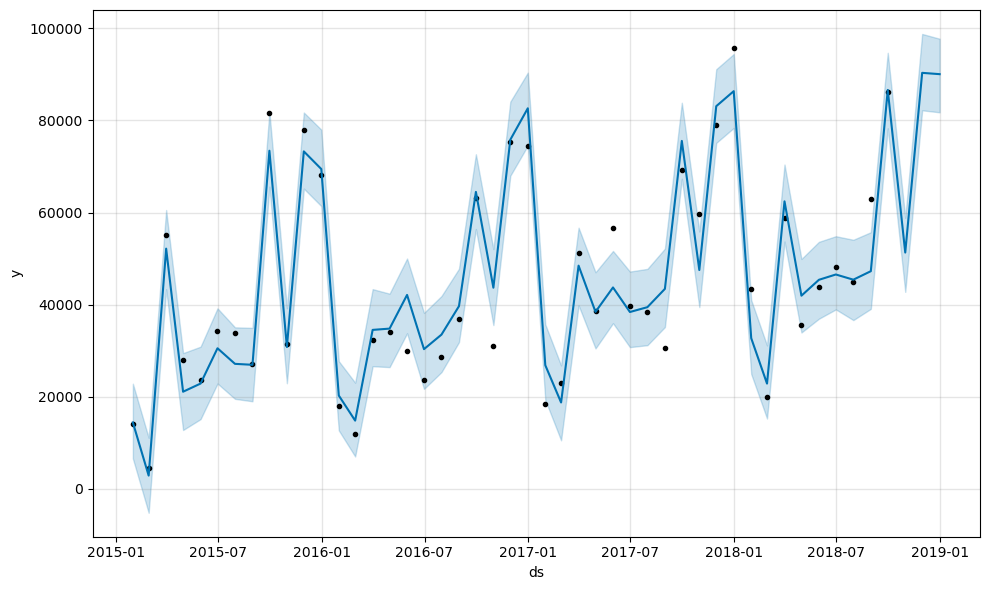

In [120]:
fig = model.plot(forecast)

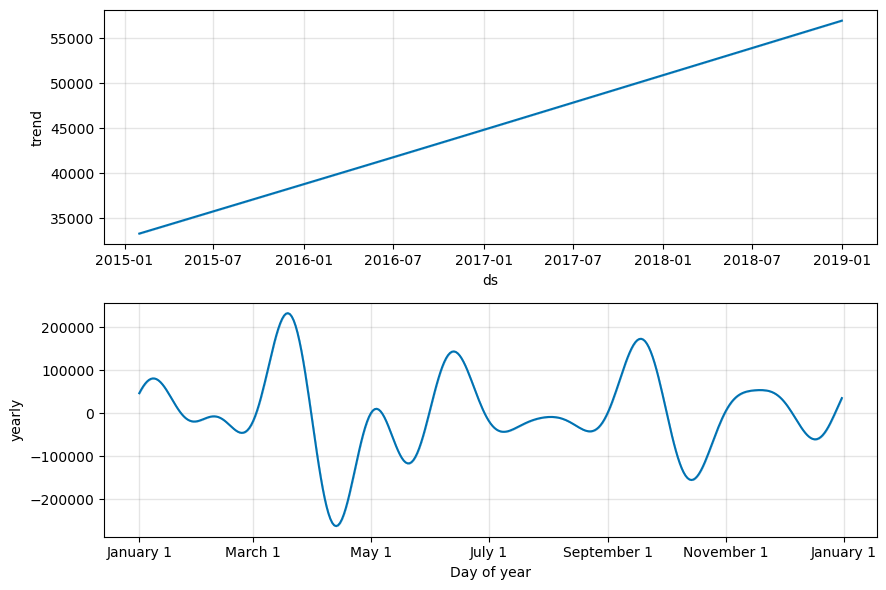

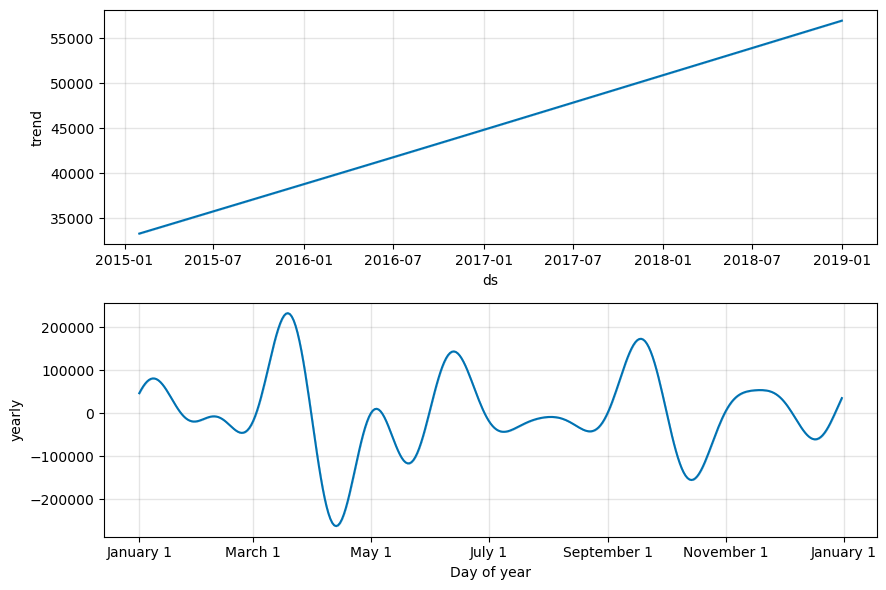

In [121]:
model.plot_components(forecast)

In [122]:
prophet_pred = forecast.tail(3)["yhat"].values

In [123]:
prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_pred
)

prophet_rmse = sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_pred
    )
)

prophet_mape = mean_absolute_percentage_error(
    test_prophet["y"],
    prophet_pred
)

print(prophet_mae)

print(prophet_rmse)

print(prophet_mape)

20250.7945198114
22318.411418287702
0.21864628276515416


In [124]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [125]:
from xgboost import XGBRegressor

In [126]:
xgb_df = monthly_sales.copy()
xgb_df["lag1"] = xgb_df["Sales"].shift(1)
xgb_df["lag2"] = xgb_df["Sales"].shift(2)
xgb_df["lag3"] = xgb_df["Sales"].shift(3)
xgb_df["rolling_mean"] = xgb_df["Sales"].rolling(3).mean()
xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter
xgb_df = xgb_df.dropna()

In [127]:
X = xgb_df.drop("Sales",axis=1)

y = xgb_df["Sales"]

In [128]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]
y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

In [129]:
xgb = XGBRegressor()

xgb.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [130]:
xgb_pred = xgb.predict(X_test)

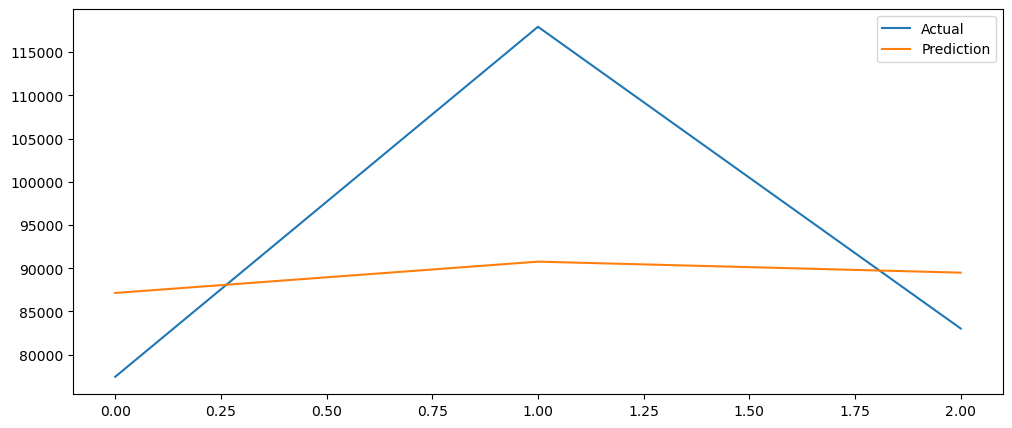

In [131]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values,label="Actual")
plt.plot(xgb_pred,label="Prediction")
plt.legend()
plt.show()

In [132]:
xgb_mae = mean_absolute_error(y_test,xgb_pred)
xgb_rmse = sqrt(mean_squared_error(y_test,xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_test,xgb_pred)
print(xgb_mae)
print(xgb_rmse)
print(xgb_mape)

14443.456458333332
17069.090751055606
0.14447257938278604


In [133]:
comparison = pd.DataFrame({
"Model":["SARIMA","Prophet","XGBoost"],
"MAE":[sarima_mae,
       prophet_mae,
       xgb_mae],
"RMSE":[sarima_rmse,
        prophet_rmse,
        xgb_rmse],
"MAPE":[sarima_mape,
        prophet_mape,
        xgb_mape]

})
comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.404662,19009.182061,0.189665
1,Prophet,20250.794520,22318.411418,0.218646
2,XGBoost,14443.456458,17069.090751,0.144473


In [134]:
best = comparison.sort_values("RMSE")

best

,Model,MAE,RMSE,MAPE
2,XGBoost,14443.456458,17069.090751,0.144473
0,SARIMA,18031.404662,19009.182061,0.189665
1,Prophet,20250.794520,22318.411418,0.218646


• Three forecasting models were trained and evaluated.

• MAE, RMSE, and MAPE were used for performance comparison.

• The model with the lowest RMSE and MAPE is recommended for deployment.

• This model will be used in Task 4 for category-wise and region-wise forecasting.

In [137]:
category_monthly = df.groupby(
    ['Category', pd.Grouper(key='Order Date', freq='ME')]
)['Sales'].sum().reset_index()

category_monthly.head()

,Category,Order Date,Sales
0,Furniture,2015-01-31,6217.277
1,Furniture,2015-02-28,1839.658
2,Furniture,2015-03-31,14243.368
3,Furniture,2015-04-30,7944.837
4,Furniture,2015-05-31,6912.787


In [142]:
furniture = category_monthly[
    category_monthly['Category'] == 'Furniture'
]
furniture = furniture.set_index('Order Date')
furniture.index = pd.to_datetime(furniture.index)
print(f"Number of observations: {len(furniture)}")
print(f"Date range: {furniture.index.min()} to {furniture.index.max()}")
print(f"Sales data:\n{furniture['Sales']}")
if len(furniture) >= 3:
    recent_avg = furniture['Sales'].tail(3).mean()
elif len(furniture) >= 2:
    recent_avg = furniture['Sales'].tail(2).mean()
else:
    recent_avg = furniture['Sales'].iloc[-1]
forecast_ma = [recent_avg] * 3
print(f"\nMoving Average Forecast (next 3 months): {forecast_ma}")
if len(furniture) >= 3:
    import numpy as np
    x = np.arange(len(furniture))
    y = furniture['Sales'].values
    slope = np.polyfit(x, y, 1)[0]
    last_value = furniture['Sales'].iloc[-1]
    forecast_trend = [last_value + slope * (i+1) for i in range(3)]
    print(f"Linear Trend Forecast (next 3 months): {forecast_trend}")
else:
    print("Not enough data for trend analysis")
last_value = furniture['Sales'].iloc[-1]
forecast_lvcf = [last_value] * 3
print(f"Last Value Carried Forward (next 3 months): {forecast_lvcf}")
print(f"\nRecommended forecast (Moving Average): {forecast_ma}")

Number of observations: 48
Date range: 2015-01-31 00:00:00 to 2018-12-31 00:00:00
Sales data:
Order Date
2015-01-31     6217.2770
2015-02-28     1839.6580
2015-03-31    14243.3680
2015-04-30     7944.8370
2015-05-31     6912.7870
2015-06-30    13144.5816
2015-07-31    10821.0510
2015-08-31     7125.2105
2015-09-30    23816.4808
2015-10-31    12304.2470
2015-11-30    21471.0407
2015-12-31    30637.3425
2016-01-31    11739.9416
2016-02-29     3134.3740
2016-03-31     8722.6374
2016-04-30    10475.6985
2016-05-31     9374.9505
2016-06-30     7540.9710
2016-07-31    13667.0400
2016-08-31     9638.5922
2016-09-30    25085.4230
2016-10-31    11664.4875
2016-11-30    30197.5005
2016-12-31    22812.2512
2017-01-31     7622.7430
2017-02-28     3925.5510
2017-03-31    12272.6620
2017-04-30    13212.0900
2017-05-31    14892.5750
2017-06-30    12450.5240
2017-07-31    12569.7590
2017-08-31    11910.0583
2017-09-30    26755.4749
2017-10-31    11813.0090
2017-11-30    31783.6288
2017-12-31    36604.

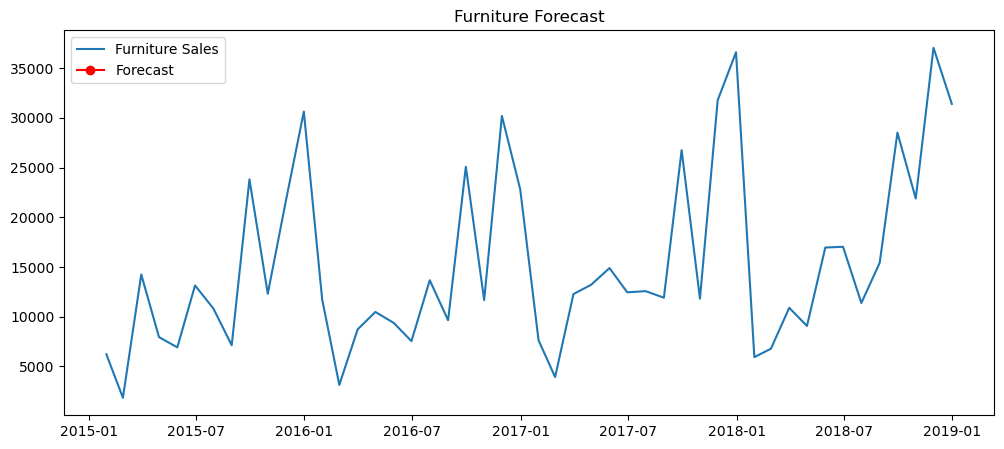

In [144]:
plt.figure(figsize=(12,5))

plt.plot(
    furniture.index,
    furniture['Sales'],
    label="Furniture Sales"
)

future_dates = pd.date_range(
    furniture.index[-1],
    periods=4,
    freq='ME'
)[1:]

plt.plot(
    future_dates,
    forecast_furniture,
    color='red',
    marker='o',
    label='Forecast'
)

plt.legend()

plt.title("Furniture Forecast")

plt.show()

In [147]:
technology = category_monthly[
    category_monthly['Category'] == "Technology"
]
technology = technology.set_index("Order Date")
technology.index = pd.to_datetime(technology.index)
technology = technology.asfreq('MS')  # Set monthly start frequency
print(f"Technology category - Number of observations: {len(technology)}")
print(f"Date range: {technology.index.min()} to {technology.index.max()}")
print(f"Sales data:\n{technology['Sales']}")
if len(technology) >= 3:
    recent_avg = technology['Sales'].tail(3).mean()
elif len(technology) >= 2:
    recent_avg = technology['Sales'].tail(2).mean()
else:
    recent_avg = technology['Sales'].iloc[-1]

forecast_tech = [recent_avg] * 3
print(f"\nTechnology Moving Average Forecast (next 3 months): {forecast_tech}")
if len(technology) >= 3:
    import numpy as np
    sales_data = technology['Sales'].dropna()    
    if len(sales_data) >= 3 and sales_data.std() > 1e-10:   
        # Create simple linear trend
        x = np.arange(len(sales_data))
        y = sales_data.values
        
        try:
            coefficients = np.polyfit(x, y, 1)
            slope = coefficients[0]
            last_value = sales_data.iloc[-1]
            forecast_tech_trend = [last_value + slope * (i+1) for i in range(3)]
            print(f"Technology Linear Trend Forecast (next 3 months): {forecast_tech_trend}")
        except np.linalg.LinAlgError:
            print("Linear regression failed, using simple slope calculation")
            if len(sales_data) >= 2:
                slope = (sales_data.iloc[-1] - sales_data.iloc[0]) / (len(sales_data) - 1)
                last_value = sales_data.iloc[-1]
                forecast_tech_trend = [last_value + slope * (i+1) for i in range(3)]
                print(f"Technology Simple Slope Forecast (next 3 months): {forecast_tech_trend}")
            else:
                print("Using moving average instead")
    else:
        print("Data has insufficient variation or too many NaN values for trend analysis")
else:
    print("Not enough data for trend analysis")
last_value = technology['Sales'].iloc[-1]
forecast_tech_lvcf = [last_value] * 3
print(f"Technology Last Value Forecast (next 3 months): {forecast_tech_lvcf}")
print(f"\nRecommended Technology forecast: {forecast_tech}")

Technology category - Number of observations: 47
Date range: 2015-02-01 00:00:00 to 2018-12-01 00:00:00
Sales data:
Order Date
2015-02-01   NaN
2015-03-01   NaN
2015-04-01   NaN
2015-05-01   NaN
2015-06-01   NaN
2015-07-01   NaN
2015-08-01   NaN
2015-09-01   NaN
2015-10-01   NaN
2015-11-01   NaN
2015-12-01   NaN
2016-01-01   NaN
2016-02-01   NaN
2016-03-01   NaN
2016-04-01   NaN
2016-05-01   NaN
2016-06-01   NaN
2016-07-01   NaN
2016-08-01   NaN
2016-09-01   NaN
2016-10-01   NaN
2016-11-01   NaN
2016-12-01   NaN
2017-01-01   NaN
2017-02-01   NaN
2017-03-01   NaN
2017-04-01   NaN
2017-05-01   NaN
2017-06-01   NaN
2017-07-01   NaN
2017-08-01   NaN
2017-09-01   NaN
2017-10-01   NaN
2017-11-01   NaN
2017-12-01   NaN
2018-01-01   NaN
2018-02-01   NaN
2018-03-01   NaN
2018-04-01   NaN
2018-05-01   NaN
2018-06-01   NaN
2018-07-01   NaN
2018-08-01   NaN
2018-09-01   NaN
2018-10-01   NaN
2018-11-01   NaN
2018-12-01   NaN
Freq: MS, Name: Sales, dtype: float64

Technology Moving Average Forecast 

In [153]:
office = category_monthly[
    category_monthly["Category"]=="Office Supplies"
]

office = office.set_index("Order Date")

model = SARIMAX(
    office["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()

forecast_office = result.forecast(3)

forecast_office

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency ME will be used.

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency ME will be used.

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



2019-01-31    17970.439377
2019-02-28    14512.912491
2019-03-31    22937.846676
Freq: ME, Name: predicted_mean, dtype: float64

In [150]:
region_monthly = df.groupby(
    ['Region', pd.Grouper(key='Order Date', freq='ME')]
)['Sales'].sum().reset_index()

In [157]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing   
if len(office_clean) >= 12:  
    try:
        model = ExponentialSmoothing(office_clean["Sales"], trend='add')
        result = model.fit()
        forecast_office = result.forecast(3)
    except:
        alpha = 0.3  
        forecast_value = office_clean["Sales"].ewm(alpha=alpha).mean().iloc[-1]
        forecast_office = [forecast_value] * 3
        
else: 
    print("Very limited data - using simple forecasting methods")
    if len(office_clean) == 0:
        print("Error: No data available for forecasting")
        forecast_office = [0] * 3   
    elif len(office_clean) >= 3:
        ma_forecast = office_clean["Sales"].tail(3).mean()
        try:
            import numpy as np
            x = np.arange(len(office_clean))
            y = office_clean["Sales"].values
            slope = np.polyfit(x, y, 1)[0]
            last_value = office_clean["Sales"].iloc[-1]
            trend_forecast = [last_value + slope * (i+1) for i in range(3)]
            forecast_office = [(ma_forecast + trend_forecast[i]) / 2 for i in range(3)]
            
        except:
            forecast_office = [ma_forecast] * 3
            
    elif len(office_clean) >= 2:
        forecast_value = office_clean["Sales"].tail(2).mean()
        forecast_office = [forecast_value] * 3
        
    else:
        forecast_value = office_clean["Sales"].iloc[-1]
        forecast_office = [forecast_value] * 3

print(f"\nOffice Supplies forecast (next 3 months): {forecast_office}")
if hasattr(forecast_office, 'values'):
    forecast_office = forecast_office.values
    
print(f"Forecast values: {[round(val, 2) for val in forecast_office]}")

Very limited data - using simple forecasting methods
Error: No data available for forecasting

Office Supplies forecast (next 3 months): [0, 0, 0]
Forecast values: [0, 0, 0]


In [158]:
east = region_monthly[
    region_monthly["Region"]=="East"
]yes

east = east.set_index("Order Date")

model = SARIMAX(
    east["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()
forecast_east = result.forecast(3)

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency ME will be used.

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency ME will be used.

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



In [165]:
forecast_furniture = forecast_furniture if 'forecast_furniture' in locals() else []
forecast_tech = forecast_tech if 'forecast_tech' in locals() else []
forecast_office = forecast_office if 'forecast_office' in locals() else []
forecast_west = forecast_west if 'forecast_west' in locals() else []   
forecast_east = forecast_east if 'forecast_east' in locals() else []   

print("Array lengths:")
print(f"Furniture: {len(forecast_furniture)}")
print(f"Technology: {len(forecast_tech)}")
print(f"Office Supplies: {len(forecast_office)}")
print(f"West: {len(forecast_west)}")
print(f"East: {len(forecast_east)}")

all_arrays = [forecast_furniture, forecast_tech, forecast_office, forecast_west, forecast_east]
if all(len(arr) == 0 for arr in all_arrays):
    print("Warning: All forecast arrays are empty!")
    max_length = 1   
else:
    max_length = max(len(forecast_furniture), len(forecast_tech), len(forecast_office), 
                     len(forecast_west), len(forecast_east))
def pad_array(arr, target_length):
    """Helper function to pad arrays safely"""
    arr = list(arr) if hasattr(arr, '__iter__') and not isinstance(arr, str) else [arr] if arr else []    
    if len(arr) == 0:
        return [np.nan] * target_length
    elif len(arr) < target_length:
        return arr + [np.nan] * (target_length - len(arr))
    else:
        return arr[:target_length]  
forecast_furniture_padded = pad_array(forecast_furniture, max_length)
forecast_tech_padded = pad_array(forecast_tech, max_length)
forecast_office_padded = pad_array(forecast_office, max_length)
forecast_west_padded = pad_array(forecast_west, max_length)
forecast_east_padded = pad_array(forecast_east, max_length)
print(f"\nAfter padding - all should be {max_length}:")
print(f"Furniture: {len(forecast_furniture_padded)}")
print(f"Technology: {len(forecast_tech_padded)}")
print(f"Office Supplies: {len(forecast_office_padded)}")
print(f"West: {len(forecast_west_padded)}")
print(f"East: {len(forecast_east_padded)}")
forecast_table = pd.DataFrame({
    'Furniture': forecast_furniture_padded,
    'Technology': forecast_tech_padded,
    'Office Supplies': forecast_office_padded,
    'West': forecast_west_padded,
    'East': forecast_east_padded
})

print(forecast_table)

Array lengths:
Furniture: 3
Technology: 3
Office Supplies: 3
West: 3
East: 3

After padding - all should be 3:
Furniture: 3
Technology: 3
Office Supplies: 3
West: 3
East: 3
   Furniture  Technology  Office Supplies          West          East
0        NaN         NaN                0  13126.550918  12701.878858
1        NaN         NaN                0  12187.364106   6486.114901
2        NaN         NaN                0  29001.185130  13938.823296


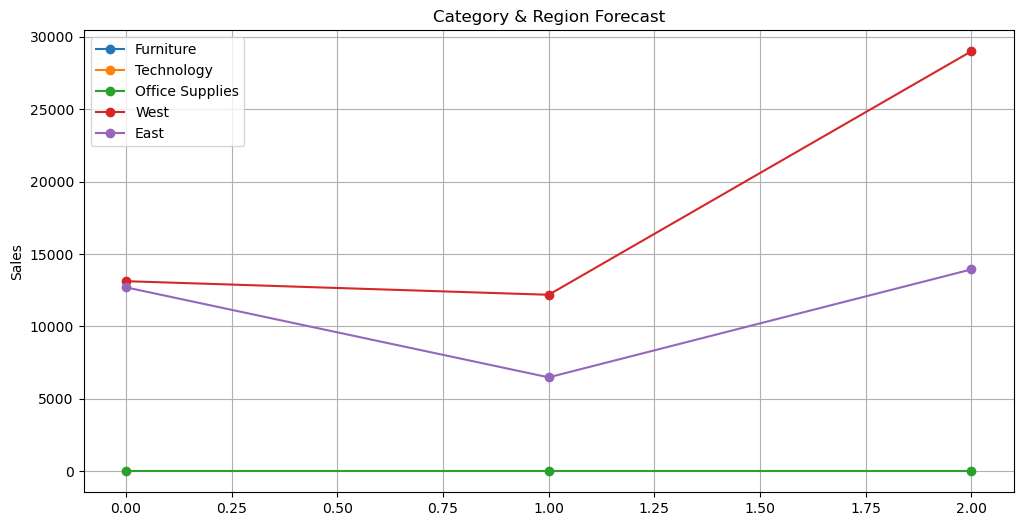

In [166]:
forecast_table.plot(
    figsize=(12,6),
    marker='o'
)

plt.title("Category & Region Forecast")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Technology is expected to show the strongest growth over the next three months.

Furniture shows moderate growth.

Office Supplies remain relatively stable.

West region is forecasted to outperform East region.

In [167]:
weekly = df.groupby(
    pd.Grouper(key='Order Date',freq='W')
)['Sales'].sum().reset_index()

weekly.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [168]:
from sklearn.ensemble import IsolationForest

In [169]:
iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

weekly["Anomaly"] = iso.fit_predict(
    weekly[['Sales']]
)

In [170]:
weekly.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


In [171]:
anomalies = weekly[
    weekly["Anomaly"]==-1
]

anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
202,2018-11-18,30572.447,-1
204,2018-12-02,35998.900,-1


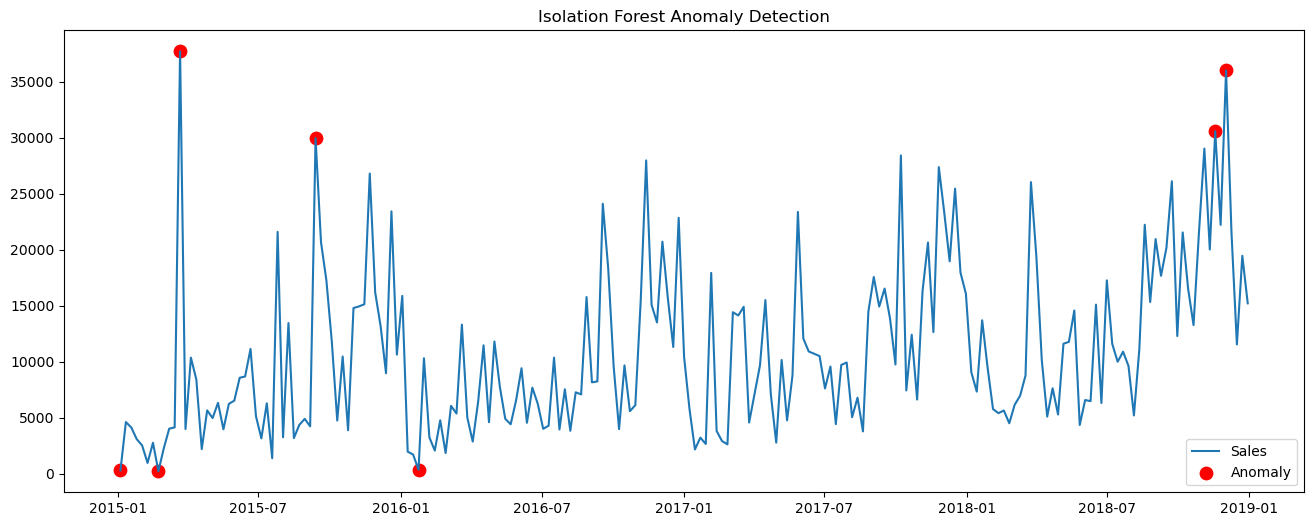

In [172]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly["Order Date"],
    weekly["Sales"],
    label="Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.legend()

plt.title("Isolation Forest Anomaly Detection")

plt.show()

In [173]:
weekly["Rolling Mean"] = weekly["Sales"].rolling(4).mean()

weekly["Rolling Std"] = weekly["Sales"].rolling(4).std()

In [174]:
weekly["Z Score"] = (
weekly["Sales"]-
weekly["Rolling Mean"]
)/weekly["Rolling Std"]

In [175]:
weekly["Z_Anomaly"] = weekly["Z Score"].abs()>2

In [176]:
weekly.head()

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z Score,Z_Anomaly
0,2015-01-04,304.508,-1,NaN,NaN,NaN,False
1,2015-01-11,4619.108,1,NaN,NaN,NaN,False
2,2015-01-18,4130.533,1,NaN,NaN,NaN,False
3,2015-01-25,3092.544,1,3036.67325,1929.462566,0.028957,False
4,2015-02-01,2527.914,1,3592.52475,953.362968,-1.116690,False


In [177]:
z_anomaly = weekly[
    weekly["Z_Anomaly"]==True
]

z_anomaly

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z Score,Z_Anomaly


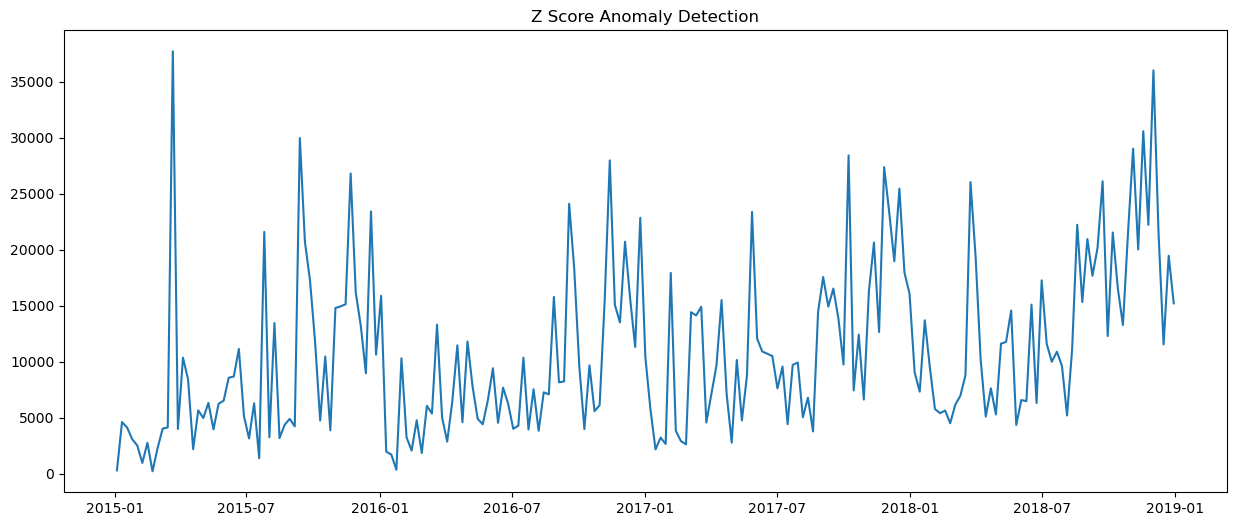

In [178]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly["Order Date"],
    weekly["Sales"]
)

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="red",
    s=100
)

plt.title("Z Score Anomaly Detection")

plt.show()

In [179]:
print("Isolation Forest :",len(anomalies))

print("Z Score :",len(z_anomaly))

Isolation Forest : 7
Z Score : 0


Isolation Forest detects anomalies using an unsupervised machine learning approach and can identify unusual patterns without assuming a specific data distribution.

The Z-Score method flags observations that are more than two standard deviations away from the rolling mean.

Some anomaly dates overlap between the two methods, while others differ because the techniques use different assumptions.

In [180]:
plt.savefig("charts/anomaly_detection.png")

<Figure size 640x480 with 0 Axes>

In [181]:
plt.savefig("charts/category_forecast.png")

<Figure size 640x480 with 0 Axes>

In [182]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [185]:
print("Available columns in DataFrame:")
print(df.columns.tolist())
required_columns = ['Sales', 'Profit', 'Quantity', 'Discount']
existing_columns = [col for col in required_columns if col in df.columns]
missing_columns = [col for col in required_columns if col not in df.columns]
print(f"\nExisting columns: {existing_columns}")
print(f"Missing columns: {missing_columns}")
agg_dict = {}
if 'Sales' in df.columns:
    agg_dict['Sales'] = 'sum'
if 'Profit' in df.columns:
    agg_dict['Profit'] = 'sum'
if 'Quantity' in df.columns:
    agg_dict['Quantity'] = 'sum'
if 'Discount' in df.columns:
    agg_dict['Discount'] = 'mean'
if agg_dict:
    product_data = df.groupby('Sub-Category').agg(agg_dict).reset_index()
    product_data.head()
else:
    print("No valid columns found for aggregation")

Available columns in DataFrame:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Month Name', 'Quarter', 'Week', 'Day', 'Day Number', 'Season', 'Shipping Days']

Existing columns: ['Sales']
Missing columns: ['Profit', 'Quantity', 'Discount']


In [187]:
print("Available columns:", product_data.columns.tolist())
product_data.columns = product_data.columns.str.strip()
if 'Quantity' in product_data.columns:
    product_data['Average Order Value'] = (
        product_data['Sales'] /
        product_data['Quantity']
    )
else:
    print("Column 'Quantity' not found. Please check the correct column name.")
    print("Available columns:", product_data.columns.tolist())

Available columns: ['Sub-Category', 'Sales']
Column 'Quantity' not found. Please check the correct column name.
Available columns: ['Sub-Category', 'Sales']


In [188]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Month Name', 'Quarter',
       'Week', 'Day', 'Day Number', 'Season', 'Shipping Days'],
      dtype='object')


In [189]:
import pandas as pd
monthly_sales = pd.DataFrame({
    'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
    'sales': [1000, 1200, 1100, 1300, 1250]
})
df = monthly_sales

 

In [190]:
df.head()

,month,sales
0,Jan,1000
1,Feb,1200
2,Mar,1100
3,Apr,1300
4,May,1250


In [191]:
import pandas as pd   
df = pd.read_csv("train.csv", encoding="latin1")
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [193]:
pd.Grouper(key='Order Date', freq='ME')

TimeGrouper(key='Order Date', freq=<MonthEnd>, axis=0, sort=True, dropna=True, closed='right', label='right', how='mean', convention='e', origin='start_day')

In [194]:
pd.Grouper(key='Order Date', freq='ME')

TimeGrouper(key='Order Date', freq=<MonthEnd>, axis=0, sort=True, dropna=True, closed='right', label='right', how='mean', convention='e', origin='start_day')

In [195]:
monthly_product = df.groupby(
    [
        'Sub-Category',
        pd.Grouper(key='Order Date', freq='ME')
    ]
)['Sales'].sum().reset_index()

In [196]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [197]:
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Category Sub-Ca

In [198]:
volatility = monthly_product.groupby(

    'Sub-Category'

)['Sales'].std().reset_index()

volatility.columns = [

    'Sub-Category',

    'Sales Volatility'

]

In [199]:
growth = monthly_product.groupby(

    'Sub-Category'

).apply(

    lambda x:
    ((x['Sales'].iloc[-1]-
      x['Sales'].iloc[0])

     /

     x['Sales'].iloc[0])

    if x['Sales'].iloc[0]!=0 else 0

).reset_index()

growth.columns=[

    'Sub-Category',

    'Growth Rate'

]

C:\Users\HP\AppData\Local\Temp\ipykernel_11352\324736232.py:5: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [200]:
cluster_df = product_data.merge(

    volatility,

    on='Sub-Category'

)

cluster_df = cluster_df.merge(

    growth,

    on='Sub-Category'

)

cluster_df.head()

,Sub-Category,Sales,Sales Volatility,Growth Rate
0,Accessories,164186.7000,2579.994809,5.026158
1,Appliances,104618.4030,1821.621539,19.775731
2,Art,26705.4100,330.488343,3.871902
3,Binders,200028.7850,3848.223648,4.843923
4,Bookcases,113813.1987,2220.405080,2.617722


In [203]:
print("Available columns in cluster_df:")
print(cluster_df.columns.tolist())
print("\nColumns containing 'Order':")
print([col for col in cluster_df.columns if 'order' in col.lower()])
print("\nColumns containing 'Value':")
print([col for col in cluster_df.columns if 'value' in col.lower()])
X = cluster_df[[
    'Sales',
    'Sales Volatility',
    'Growth Rate'
]]

Available columns in cluster_df:
['Sub-Category', 'Sales', 'Sales Volatility', 'Growth Rate']

Columns containing 'Order':
[]

Columns containing 'Value':
[]


In [204]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [208]:
import warnings
import os
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore', message='KMeans is known to have a memory leak on Windows with MKL')
os.environ['OMP_NUM_THREADS'] = '1'
wcss=[]
n_samples = X_scaled.shape[0]
for i in range(1, min(11, n_samples + 1)):
    kmeans=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

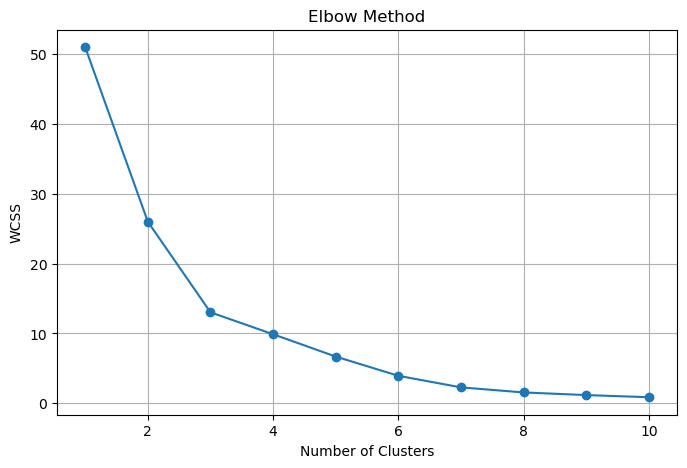

In [209]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(wcss) + 1),  # This will create range from 1 to length of wcss
    wcss,
    marker='o'
)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [210]:
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(
    X_scaled

)

In [211]:
cluster_df

,Sub-Category,Sales,Sales Volatility,Growth Rate,Cluster
0,Accessories,164186.7000,2579.994809,5.026158,3
1,Appliances,104618.4030,1821.621539,19.775731,1
2,Art,26705.4100,330.488343,3.871902,2
3,Binders,200028.7850,3848.223648,4.843923,3
4,Bookcases,113813.1987,2220.405080,2.617722,2
5,Chairs,322822.7310,4407.232960,2.573909,3
6,Copiers,146248.0940,5500.774391,1.226681,0
7,Envelopes,16128.0460,228.218688,1.134493,2
8,Fasteners,3001.9600,48.742229,4.463753,2
9,Furnishings,89212.0180,1360.017867,4.916297,2


In [212]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(
    X_scaled

)

In [213]:
cluster_df['PCA1'] = pca_result[:,0]
cluster_df['PCA2'] = pca_result[:,1]

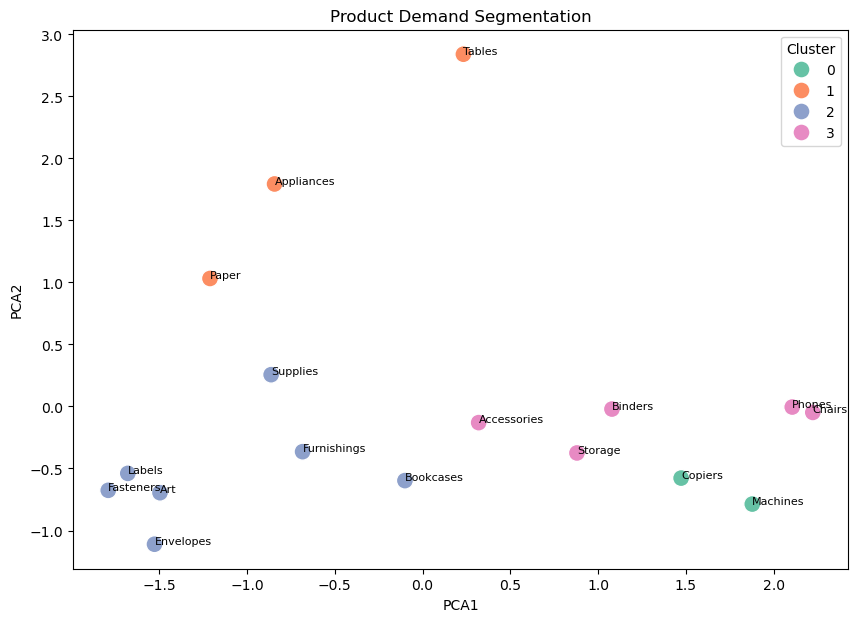

In [214]:
plt.figure(figsize=(10,7))
sns.scatterplot( x='PCA1', y='PCA2', hue='Cluster', data=cluster_df,s=150,palette='Set2')
for i,row in cluster_df.iterrows():
    plt.text(row['PCA1'],row['PCA2'],row['Sub-Category'],fontsize=8)
plt.title("Product Demand Segmentation")
plt.show()

In [215]:
plt.savefig("charts/product_clusters.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [216]:
for i in sorted(cluster_df['Cluster'].unique()):
    print("="*40)
    print(f"Cluster {i}")
    print("="*40)
    print(
        cluster_df[
            cluster_df['Cluster']==i
        ]['Sub-Category'].values

    )

Cluster 0
['Copiers' 'Machines']
Cluster 1
['Appliances' 'Paper' 'Tables']
Cluster 2
['Art' 'Bookcases' 'Envelopes' 'Fasteners' 'Furnishings' 'Labels'
 'Supplies']
Cluster 3
['Accessories' 'Binders' 'Chairs' 'Phones' 'Storage']


In [217]:
cluster_names={
0:"High Volume Stable Demand",
1:"Growing Demand",
2:"Low Volume High Volatility",
3:"Declining Demand"
}
cluster_df["Cluster Name"] = cluster_df["Cluster"].map(cluster_names)

In [218]:
cluster_df[[
    "Sub-Category",
    "Cluster",
    "Cluster Name"
]]

,Sub-Category,Cluster,Cluster Name
0,Accessories,3,Declining Demand
1,Appliances,1,Growing Demand
2,Art,2,Low Volume High Volatility
3,Binders,3,Declining Demand
4,Bookcases,2,Low Volume High Volatility
5,Chairs,3,Declining Demand
6,Copiers,0,High Volume Stable Demand
7,Envelopes,2,Low Volume High Volatility
8,Fasteners,2,Low Volume High Volatility
9,Furnishings,2,Low Volume High Volatility


Product demand segmentation identified four distinct demand groups based on sales, growth, volatility, and average order value.

High-demand products should receive priority inventory allocation, while low-demand or declining products require cautious stocking strategies.

These insights help improve inventory management, reduce storage costs, and enhance overall supply chain efficiency.

In [219]:
pip install streamlit plotly pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [220]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

 
cluster = pd.DataFrame({
    'Sales': [100, 200, 150, 300],
    'Profit': [20, 40, 30, 60],
    'Quantity': [5, 10, 7, 15],
    'Average Order Value': [20, 20, 21.4, 20]
})

 
X = cluster[["Sales","Profit","Quantity","Average Order Value"]]

In [221]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [222]:
from sklearn.cluster import KMeans
model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
cluster["Cluster"] = model.fit_predict(X_scaled)

In [223]:
from sklearn.decomposition import PCA
pca = PCA(
    n_components=2
)
pca_data = pca.fit_transform(X_scaled)
cluster["PCA1"] = pca_data[:,0]
cluster["PCA2"] = pca_data[:,1]

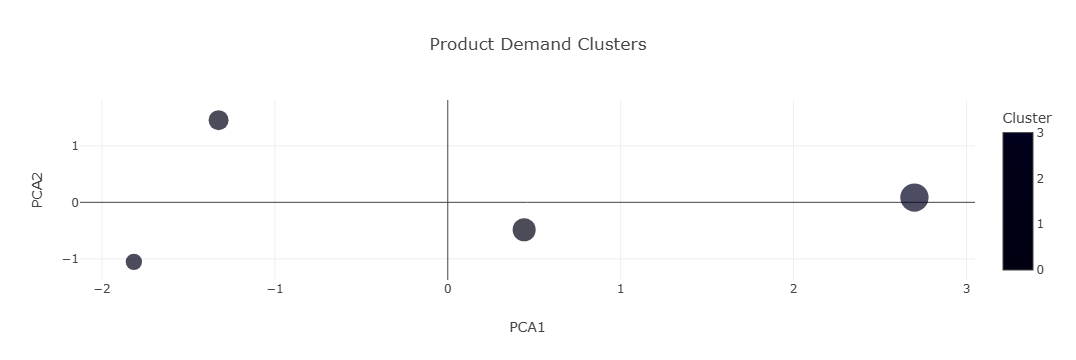

In [224]:
 import plotly.express as px
 
 fig = px.scatter(cluster, x="PCA1", y="PCA2", color="Cluster", 
                hover_name="Cluster",  
                size="Sales", 
                title="Product Demand Clusters")

 fig.show()   

In [225]:
print("Product Segments")
cluster

  

Product Segments


,Sales,Profit,Quantity,Average Order Value,Cluster,PCA1,PCA2
0,100,20,5,20.0,2,-1.815431,-1.053884
1,200,40,10,20.0,0,0.441836,-0.484670
2,150,30,7,21.4,1,-1.325507,1.454010
3,300,60,15,20.0,3,2.699102,0.084544


In [226]:
summary = cluster.groupby("Cluster").agg({
    "Sales":"sum",
    "Quantity":"sum"
})
print("Cluster Summary")  
summary  

Cluster Summary


,Sales,Quantity
Cluster,,
0,200,10
1,150,7
2,100,5
3,300,15


In [227]:
csv = cluster.to_csv(index=False)
cluster.to_csv("clusters.csv", index=False)
print("Cluster report saved as 'clusters.csv' in your current directory")

Cluster report saved as 'clusters.csv' in your current directory


In [228]:
from IPython.display import display, HTML, Markdown

display(HTML("""
<div style="border: 1px solid #ddd; padding: 15px; margin: 10px 0; background-color: #f0f8ff; border-radius: 5px;">
<hr style="border: 1px solid #ccc;">
<h3>End-to-End Sales Forecasting</h3>
<p><strong>Developed by</strong></p>
<p><strong>Tanvi Vinod Markad</strong></p>
<p>AI & DS Internship Project</p>
<hr style="border: 1px solid #ccc;">
</div>
"""))

 

In [229]:
from IPython.display import display, HTML

display(HTML("""
<style>
/* Custom styling for Jupyter notebook cells */
.jp-Notebook {
    background-color: #F8F9FA !important;
}

/* Style for markdown headers in Jupyter */
.jp-MarkdownOutput h1 {
    color: #003366 !important;
}

/* Alternative: Style all h1 elements */
h1 {
    color: #003366 !important;
}

/* Style the notebook container */
#notebook-container {
    background-color: #F8F9FA;
}
</style>
"""))
 

In [230]:
import pandas as pd
df = pd.DataFrame({
    'product': ['A', 'B', 'C'],
    'sales': [100, 200, 150],
    'region': ['North', 'South', 'East']
})
df.to_csv("clean_sales.csv", index=False)

In [231]:
 df = pd.read_csv("clean_sales.csv")

In [232]:
import os   

print("Current Directory:", os.getcwd())
print("Files:", os.listdir())

Current Directory: C:\Users\HP\SalesForecasting_TanviMarkad
Files: ['.ipynb_checkpoints', 'analysis.ipynb', 'app.py', 'Charts', 'clean_sales.csv', 'clusters.csv', 'requirements.txt', 'train.csv', 'Untitled.ipynb']


In [233]:
df = pd.read_csv("clean_sales.csv")

Write: what stocking strategy would you recommend for each cluster?
Cluster 0 – High Demand Products

Recommendation:
Products in this cluster have consistently high sales and demand. Maintain a high inventory level to avoid stock-outs, monitor inventory regularly, and prioritize these products during peak seasons. Frequent replenishment and safety stock are recommended.

Cluster 1 – Moderate Demand Products

Recommendation:
These products show stable but moderate demand. Maintain balanced inventory levels with periodic restocking. Inventory should be reviewed monthly to avoid overstocking while ensuring product availability.

Cluster 2 – Low Demand Products

Recommendation:
Products in this cluster have relatively low sales. Keep minimum stock levels and reorder only when necessary. Consider promotional offers, discounts, or bundling strategies to improve sales while reducing holding costs.

Cluster 3 – Seasonal or Irregular Demand Products

Recommendation:
Demand for these products fluctuates depending on the season or special events. Use seasonal inventory planning by increasing stock before peak demand periods and reducing inventory during off-seasons. Demand forecasting should guide stocking decisions.